In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import logging
logger = tf.get_logger()
logger.setLevel(logging.ERROR)

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from sklearn.metrics import confusion_matrix

In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input

train_datagen = image.ImageDataGenerator(
    preprocessing_function=preprocess_input,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
)
validation_datagen = image.ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [ ]:
train = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/Research/original_data_leveling/up_train',
    target_size = (224, 224),
    batch_size = 32,
    class_mode = 'categorical'
)

validation = validation_datagen.flow_from_directory(
    '/content/drive/MyDrive/Research/original_data_leveling/up_val',
    target_size = (224, 224),
    batch_size = 32,
    class_mode = 'categorical'
)

test = validation_datagen.flow_from_directory(
    '/content/drive/MyDrive/Research/original_data_leveling/up_test',
    target_size = (224, 224),
    batch_size = 32,
    shuffle = False,
    class_mode = 'categorical'
)

Found 10500 images belonging to 3 classes.
Found 1500 images belonging to 3 classes.
Found 3000 images belonging to 3 classes.


In [ ]:
ResNet50 = tf.keras.applications.ResNet50(
    include_top=False,
    weights = None,
    input_shape=(224,224,3),
    )

In [ ]:
ResNet50.trainable = True

In [ ]:
model = tf.keras.models.Sequential([
  ResNet50,
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dropout(0.8),
  tf.keras.layers.Dense(units=1024, activation='relu'),
  tf.keras.layers.Dense(units=512, activation='relu'),
  tf.keras.layers.Dense(units=3, activation='softmax'),
])

In [ ]:
model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │   102,761,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,875,523 (483.99 MB)

 Trainable params: 126,822,403 (483.79 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [ ]:
history = model.fit(
    x = train,
    validation_data = validation,
    epochs = 10
)

Epoch 1/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 8789s 27s/step - accuracy: 0.7583 - loss: 1.3649 - val_accuracy: 0.8540 - val_loss: 0.3536
Epoch 2/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 220s 666ms/step - accuracy: 0.8835 - loss: 0.2831 - val_accuracy: 0.9293 - val_loss: 0.1713
Epoch 3/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 220s 668ms/step - accuracy: 0.9081 - loss: 0.2783 - val_accuracy: 0.3607 - val_loss: 122466.7656
Epoch 4/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 215s 653ms/step - accuracy: 0.9021 - loss: 0.2518 - val_accuracy: 0.9427 - val_loss: 0.1477
Epoch 5/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 214s 649ms/step - accuracy: 0.9369 - loss: 0.1686 - val_accuracy: 0.9553 - val_loss: 0.1216
Epoch 6/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 216s 655ms/step - accuracy: 0.9465 - loss: 0.1449 - val_accuracy: 0.9253 - val_loss: 0.2475
Epoch 7/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 213s 646ms/step - accuracy: 0.8846 - loss: 0.6353 - val_accuracy: 0.3373 - val_loss: 21493146.0000
Epoch 8/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 211s 640ms/step - accurac

In [ ]:
# Evaluate the loss and accuracy
loss, accuracy = model.evaluate(test)

# Print the accuracy
print("Accuracy: " + str(accuracy))
# Print the loss
print("Loss: " + str(loss))

94/94 ━━━━━━━━━━━━━━━━━━━━ 1414s 15s/step - accuracy: 0.8970 - loss: 0.3090
Accuracy: 0.8970000147819519
Loss: 0.3090045750141144


In [ ]:
test.class_indices

{'Lung_Adenocarcinoma': 0,
 'Lung_Benign_Tissue': 1,
 'Lung_Squamos_Cell_Carcinoma': 2}

In [ ]:
import numpy as np
from sklearn import metrics

predictions = model.predict(test)
predicted_classes = np.argmax(predictions, axis = 1)
true_classes = test.classes
class_labels = ['Lung_Adenocarcinoma', 'Lung_Benign_Tissue', 'Lung_Squamous_Cell_Carcinoma']
report = metrics.classification_report(true_classes, predicted_classes, target_names = class_labels)
print(report)

94/94 ━━━━━━━━━━━━━━━━━━━━ 19s 198ms/step
                              precision    recall  f1-score   support

         Lung_Adenocarcinoma       0.81      0.90      0.85      1000
          Lung_Benign_Tissue       0.97      0.98      0.97      1000
Lung_Squamous_Cell_Carcinoma       0.92      0.81      0.87      1000

                    accuracy                           0.90      3000
                   macro avg       0.90      0.90      0.90      3000
                weighted avg       0.90      0.90      0.90      3000



<Axes: >

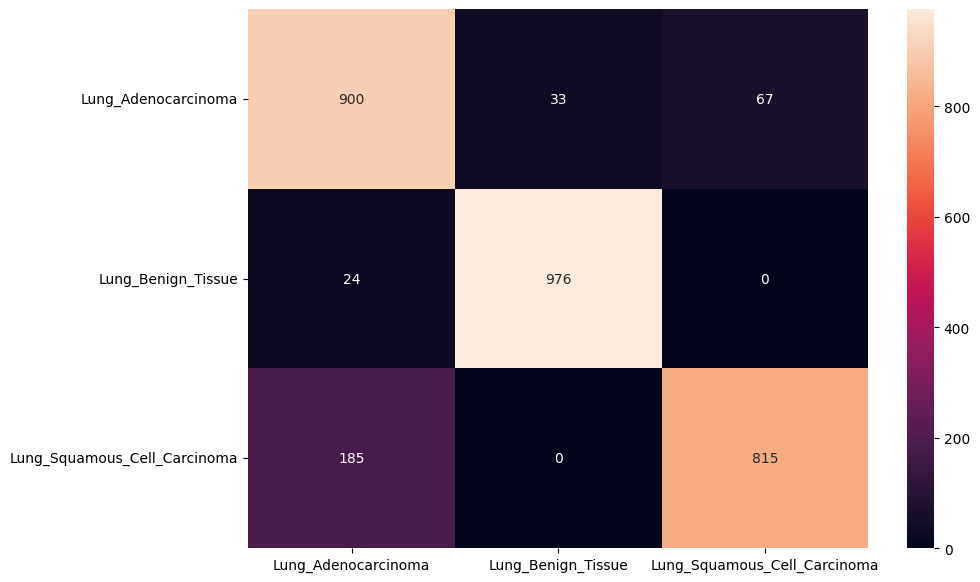

In [ ]:
import seaborn as sn
import pandas as pd
import matplotlib.pyplot as plt

# Label order MUST match test.class_indices: Adenocarcinoma=0, Benign=1, Squamous=2
labels = ['Lung_Adenocarcinoma', 'Lung_Benign_Tissue', 'Lung_Squamous_Cell_Carcinoma']
cm = metrics.confusion_matrix(true_classes, predicted_classes)
df_cm = pd.DataFrame(cm, index=labels, columns=labels)
plt.figure(figsize = (10,7))
sn.heatmap(df_cm, annot=True, fmt='d')

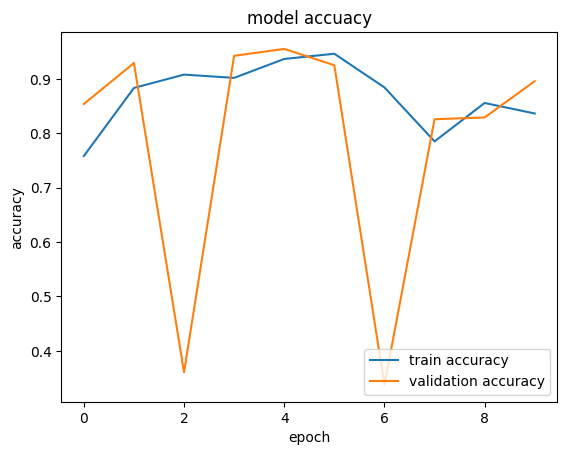

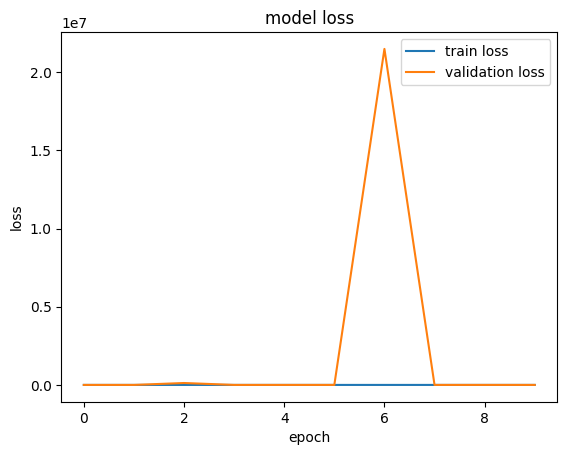

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("model accuacy")
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train accuracy', 'validation accuracy'], loc='lower right')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train loss', 'validation loss'], loc='upper right')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
models = ['MobileNetV2',  'VGG19', 'ResNet50']
accuracy = [97.8,  95.0, 98.9]   # use your real test numbers
plt.bar(models, accuracy, color='steelblue')
plt.ylim(90, 100)
plt.ylabel('Test Accuracy (%)')
plt.title('Model Comparison on LC25000 Lung Classes')
for i, v in enumerate(accuracy):
    plt.text(i, v+0.1, f'{v}%', ha='center')
plt.show()